# 02 - Preprocessing ESA-ADB Mission1 Dataset

**What we know from EDA (01_explore_esa_adb.ipynb):**
- `id` (int index) + 87 channels + `is_anomaly`
- Starter channels: `channel_41` -> `channel_46` (all float32, range ~0.75–0.85)
- No missing values, no high-skew, no near-zero variance on starter channels
- Anomaly ratio: 10.48% -> `pos_weight = 8.5`

**Objectives:**
- Scale starter channels with `StandardScaler` (fit on train only)
- Build sliding-window tensors (window=64, stride=1)
- Save `X_train`, `y_train`, `X_test` to `data/processed/`
- Validate shapes and label distribution after windowing

---
## Imports & Paths

In [1]:
import json
import warnings
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

ROOT = Path("..")
DATA_RAW = ROOT / "data" / "raw" / "ESA-Mission1"
DATA_PROC = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results" / "metrics"
FIGURES_DIR = ROOT / "results" / "figures"
MODELS_DIR = ROOT / "models" / "baseline"

for d in [DATA_PROC, RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_RAW / "train.parquet"
TEST_PATH = DATA_RAW / "test.parquet"
TARGETS_PATH = DATA_RAW / "target_channels.csv"

for p in [TRAIN_PATH, TEST_PATH, TARGETS_PATH]:
    status = "File exist :" if p.exists() else "Missing file"
    print(f"{status} {p}")

File exist : ../data/raw/ESA-Mission1/train.parquet
File exist : ../data/raw/ESA-Mission1/test.parquet
File exist : ../data/raw/ESA-Mission1/target_channels.csv


---
## Load Data

In [2]:
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)
targets = pd.read_csv(TARGETS_PATH)

ID_COL = "id"
LABEL_COL = "is_anomaly"

starter_cols = [f"channel_{i}" for i in range(41, 47)]
target_channel_list = targets["target_channels"].tolist()
telecommand_cols = [c for c in train.columns if c.startswith("telecommand_")]
exclude = set(target_channel_list + telecommand_cols + [ID_COL, LABEL_COL])
auxiliary_cols = [c for c in train.columns if c not in exclude]

print(f"train set        : {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"test set         : {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"Starter channels : {starter_cols}")

train set        : 14,728,321 rows x 89 columns
test set         : 521,280 rows x 88 columns
Starter channels : ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']


---
## Extract Starter channels

In [3]:
X_raw_train = train[starter_cols].values.astype(np.float32)
X_raw_test  = test[starter_cols].values.astype(np.float32)
y_train_raw = train[LABEL_COL].values.astype(np.int8)

print(f"X_raw_train : {X_raw_train.shape}  dtype={X_raw_train.dtype}")
print(f"X_raw_test  : {X_raw_test.shape}    dtype={X_raw_test.dtype}")
print(f"y_train_raw : {y_train_raw.shape}    dtype={y_train_raw.dtype}")

print(f"\nValue ranges (train):")
for i, col in enumerate(starter_cols):
    print(f"     {col}  min={X_raw_train[:, i].min():.4f}  "
          f"max={X_raw_train[:, i].max():.4f}  "
          f"mean={X_raw_train[:, i].mean():.4f}")

X_raw_train : (14728321, 6)  dtype=float32
X_raw_test  : (521280, 6)    dtype=float32
y_train_raw : (14728321,)    dtype=int8

Value ranges (train):
     channel_41  min=0.0000  max=0.9821  mean=0.8082
     channel_42  min=0.0000  max=0.9663  mean=0.7821
     channel_43  min=0.0000  max=0.9507  mean=0.7686
     channel_44  min=0.0000  max=0.9755  mean=0.7940
     channel_45  min=0.0000  max=1.0000  mean=0.8104
     channel_46  min=0.0000  max=0.9595  mean=0.7656


---
## StandardScaler

In [4]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_raw_train)
X_scaled_test = scaler.transform(X_raw_test)

print("Scaler fitted on train:")
print(f"  mean_  : {scaler.mean_}")
print(f"  scale_ : {scaler.scale_}")

print(f"\nAfter scaling (train), mean~0, std~1 :")
for i, col in enumerate(starter_cols):
    print(f"     {col}  mean={X_scaled_train[:, i].mean():.4f}  "
          f"std={X_scaled_train[:, i].std():.4f}")

Scaler fitted on train:
  mean_  : [0.80820819 0.78212123 0.76856942 0.79400993 0.81038033 0.76562342]
  scale_ : [0.03117312 0.03104107 0.0319415  0.03466514 0.03144005 0.03055148]

After scaling (train), mean~0, std~1 :
     channel_41  mean=-0.0000  std=1.0000
     channel_42  mean=0.0000  std=1.0000
     channel_43  mean=-0.0000  std=1.0000
     channel_44  mean=-0.0000  std=1.0000
     channel_45  mean=0.0000  std=1.0000
     channel_46  mean=-0.0000  std=1.0000


In [5]:
# Saving scaler
scaler_path = MODELS_DIR / "scaler_starter_channels.pkl"
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

Scaler saved to ../models/baseline/scaler_starter_channels.pkl


---
## Sliding Window Construction

A sliding window is recommended because the data is a continuous time series while most ML models need fixed-size inputs. The window turns the raw stream into training samples of the form “past input -> output” which is a standard way to prepare time-series data for learning.

In other word, it converts the scaled 1D time series into overlapping windows for model input.

- **window_size = 64** : 64 consecutive time steps per sample
- **stride = 1**       : one step forward between windows (maximum overlap)
- **Label strategy**   : a window is labelled `1` if **any** point inside is anomalous

Sources :

1. [Sliding Window method in time series analysis](https://lazyprogrammer.me/what-is-the-sliding-window-method-in-time-series-analysis/)

2. [Medium's article about Sliding Window](https://medium.com/data-science/sliding-windows-in-pandas-40b79edefa34)

3. [Github issue - Sliding Window function](https://github.com/numpy/numpy/issues/7753)

In [6]:
def sliding_windows(X: np.ndarray,
                    y: np.ndarray | None,
                    window_size: int = 64,
                    stride: int = 1) -> tuple:
    """
    Build overlapping sliding windows from a multivariate time series.

    Parameters
    X           : (n_timesteps, n_features)
    y           : (n_timesteps,) or None, labels (optional, e.g. test set)
    window_size : number of timesteps per window
    stride      : step between consecutive windows

    Returns
    X_win : (n_windows, window_size, n_features)
    y_win : (n_windows,), 1 if any point in window is anomalous else 0
            returns None if y is None
    """
    n = X.shape[0]
    indices = range(0, n - window_size + 1, stride)
    X_win   = np.stack([X[i : i + window_size] for i in indices], axis=0)
    y_win   = None
    if y is not None:
        y_win = np.array([int(y[i : i + window_size].any()) for i in indices],
                         dtype=np.int8)
    return X_win, y_win

WINDOW_SIZE = 64
STRIDE = 1

print(f"Window size : {WINDOW_SIZE}")
print(f"Stride      : {STRIDE}")
print(f"Expected windows (train) : ~{(len(train) - WINDOW_SIZE) // STRIDE + 1:,}")
print(f"Expected windows (test)  : ~{(len(test)  - WINDOW_SIZE) // STRIDE + 1:,}")

Window size : 64
Stride      : 1
Expected windows (train) : ~14,728,258
Expected windows (test)  : ~521,217


In [7]:
import time

print("Building train windows")
t0 = time.perf_counter()
X_train, y_train = sliding_windows(X_scaled_train, y_train_raw,
                                   window_size=WINDOW_SIZE, stride=STRIDE)
train_time = time.perf_counter() - t0
print(f"Train windows built in {train_time:.2f} s")

print("Building test windows")
t0 = time.perf_counter()
X_test, _        = sliding_windows(X_scaled_test, None,
                                   window_size=WINDOW_SIZE, stride=STRIDE)
test_time = time.perf_counter() - t0
print(f"Test windows built in {test_time:.2f} s")

print(f"\nX_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"y_train : {y_train.shape}        dtype={y_train.dtype}")
print(f"X_test  : {X_test.shape}    dtype={X_test.dtype}")
print(f"\nMemory usage:")
print(f"     X_train : {X_train.nbytes / 1e9:.2f} GB")
print(f"     X_test  : {X_test.nbytes  / 1e9:.2f} GB")

Building train windows
Train windows built in 37.25 s
Building test windows
Test windows built in 0.47 s

X_train : (14728258, 64, 6)  dtype=float32
y_train : (14728258,)        dtype=int8
X_test  : (521217, 64, 6)    dtype=float32

Memory usage:
     X_train : 22.62 GB
     X_test  : 0.80 GB


---
## Label Distribution After Windowing

Windowing with `any()` labelling can sometimes inflates the anomaly ratio; a window is positive if **at least one** of its 64 points is anomalous. The new ratio needs to be understood before training.

Sources :

1. [Labelling technique for sliding window](https://stats.stackexchange.com/questions/318240/supervised-learning-setting-labels-on-sliding-windows-of-sensor-data)

2. [Adaptative sliding window for anomaly detection](https://www.researchgate.net/publication/357688386_An_adaptive_sliding_window_for_anomaly_detection_of_time_series_in_wireless_sensor_networks)

In [8]:
n_win_total = len(y_train)
n_win_anomaly = int(y_train.sum())
n_win_normal = n_win_total - n_win_anomaly
win_ratio = n_win_anomaly / n_win_total * 100
pos_weight = n_win_normal / max(n_win_anomaly, 1)

print(f"{'Window-level label stats :'}")
print(f"    Total windows  : {n_win_total:,}")
print(f"    Normal  (0)    : {n_win_normal:,}  ({100 - win_ratio:.2f} %)")
print(f"    Anomaly (1)    : {n_win_anomaly:,}   ({win_ratio:.2f} %)")
print(f"    pos_weight     : {pos_weight:.2f}")
print(f"\n    Point-level ratio was : 10.48 %")
print(f"    Window-level ratio is : {win_ratio:.2f} %")

Window-level label stats :
    Total windows  : 14,728,258
    Normal  (0)    : 13,172,392  (89.44 %)
    Anomaly (1)    : 1,555,866   (10.56 %)
    pos_weight     : 8.47

    Point-level ratio was : 10.48 %
    Window-level ratio is : 10.56 %


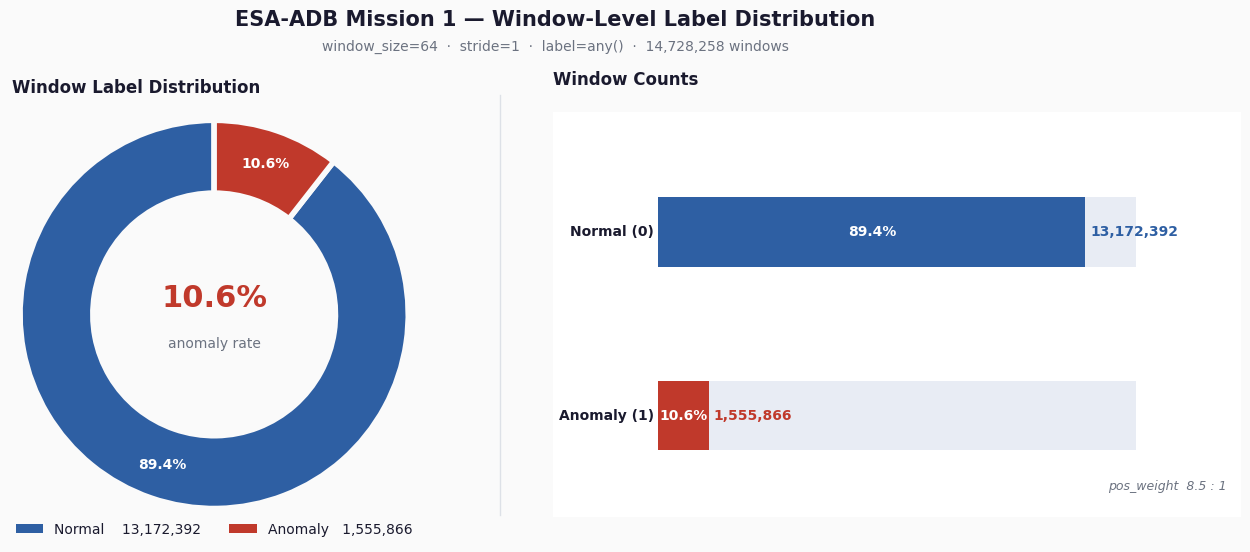

In [9]:
BG        = "#FAFAFA"
PANEL     = "#FFFFFF"
NORMAL_C  = "#2E5FA3"
ANOMALY_C = "#C0392B"
TEXT_DARK = "#1A1A2E"
TEXT_GRAY = "#6B7280"
ACCENT    = "#E8ECF4"

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Donut
_, _, autotexts = axes[0].pie(
    [n_win_normal, n_win_anomaly],
    colors=[NORMAL_C, ANOMALY_C],
    startangle=90,
    autopct="%1.1f%%",
    pctdistance=0.82,
    radius=1.2,
    wedgeprops={"edgecolor": BG, "linewidth": 4, "width": 0.45},
    labeldistance=1.15,
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_color("white")
    at.set_fontweight("bold")

axes[0].text(0,  0.10, f"{win_ratio:.1f}%", ha="center", va="center",
             fontsize=22, fontweight="bold", color=ANOMALY_C)
axes[0].text(0, -0.18, "anomaly rate",      ha="center", va="center",
             fontsize=10, color=TEXT_GRAY)

from matplotlib.patches import Patch
axes[0].legend(
    handles=[
        Patch(facecolor=NORMAL_C,  label=f"Normal    {n_win_normal:,}"),
        Patch(facecolor=ANOMALY_C, label=f"Anomaly   {n_win_anomaly:,}"),
    ],
    loc="lower center", bbox_to_anchor=(0.5, -0.08),
    frameon=False, fontsize=10, labelcolor=TEXT_DARK, ncol=2
)
axes[0].set_title("Window Label Distribution", fontsize=12, fontweight="bold",
                  color=TEXT_DARK, pad=14, loc="left")

# Horizontal bars
for yi, val, color, lab in zip([1, 0],
                                [n_win_normal, n_win_anomaly],
                                [NORMAL_C, ANOMALY_C],
                                ["Normal (0)", "Anomaly (1)"]):
    axes[1].barh(yi, n_win_total, height=0.38, color=ACCENT, zorder=1)
    axes[1].barh(yi, val,         height=0.38, color=color,  zorder=2)
    axes[1].text(-n_win_total * 0.01, yi, lab,
                 ha="right", va="center", fontsize=10,
                 fontweight="bold", color=TEXT_DARK)
    axes[1].text(val + n_win_total * 0.01, yi, f"{val:,}",
                 ha="left", va="center", fontsize=10,
                 color=color, fontweight="bold")
    axes[1].text(val / 2, yi, f"{val/n_win_total*100:.1f}%",
                 ha="center", va="center", fontsize=10,
                 color="white", fontweight="bold")

axes[1].set_xlim(-n_win_total * 0.22, n_win_total * 1.22)
axes[1].set_ylim(-0.55, 1.65)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_title("Window Counts", fontsize=12, fontweight="bold",
                  color=TEXT_DARK, pad=20, loc="left")
axes[1].text(0.98, 0.06, f"pos_weight  {pos_weight:.1f} : 1",
             transform=axes[1].transAxes, ha="right", va="bottom",
             fontsize=9, color=TEXT_GRAY, style="italic")

fig.add_artist(plt.Line2D([0.46, 0.46], [0.08, 0.92],
               transform=fig.transFigure, color="#DDE1E7", linewidth=1))
fig.text(0.5, 1.06, "ESA-ADB Mission 1 — Window-Level Label Distribution",
         ha="center", fontsize=15, fontweight="bold", color=TEXT_DARK)
fig.text(0.5, 1.01,
         f"window_size={WINDOW_SIZE}  ·  stride={STRIDE}  ·  "
         f"label=any()  ·  {n_win_total:,} windows",
         ha="center", fontsize=10, color=TEXT_GRAY)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "window_label_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Validate Windows

In [10]:
# Shape checks
assert X_train.shape[1] == WINDOW_SIZE,           "Wrong window size in X_train"
assert X_train.shape[2] == len(starter_cols),     "Wrong channel count in X_train"
assert X_test.shape[1] == WINDOW_SIZE,            "Wrong window size in X_test"
assert len(y_train) == len(X_train),              "X_train / y_train length mismatch"
assert set(np.unique(y_train)).issubset({0, 1}),   "Unexpected label values"
print("OK : All shape and label checks passed")

# Random window inspection
np.random.seed(seed=42)
idx = np.random.randint(len(X_train))
sample = X_train[idx]      # (64, 6)
label = y_train[idx]       # label 1 = anomaly, 0 = normal

print(f"\nRandom window index : {idx:,}")
print(f"     Shape  : {sample.shape}")
print(f"     Label  : {label}  ({'ANOMALY' if label else 'NORMAL'})")
print(f"     Mean per channel : {sample.mean(axis=0).round(4)}")
print(f"     Std  per channel : {sample.std(axis=0).round(4)}")

OK : All shape and label checks passed

Random window index : 6,423,388
     Shape  : (64, 6)
     Label  : 0  (NORMAL)
     Mean per channel : [0.0312 0.1514 0.0489 0.0391 0.1305 0.0014]
     Std  per channel : [0.1411 0.1759 0.098  0.1518 0.1118 0.1417]


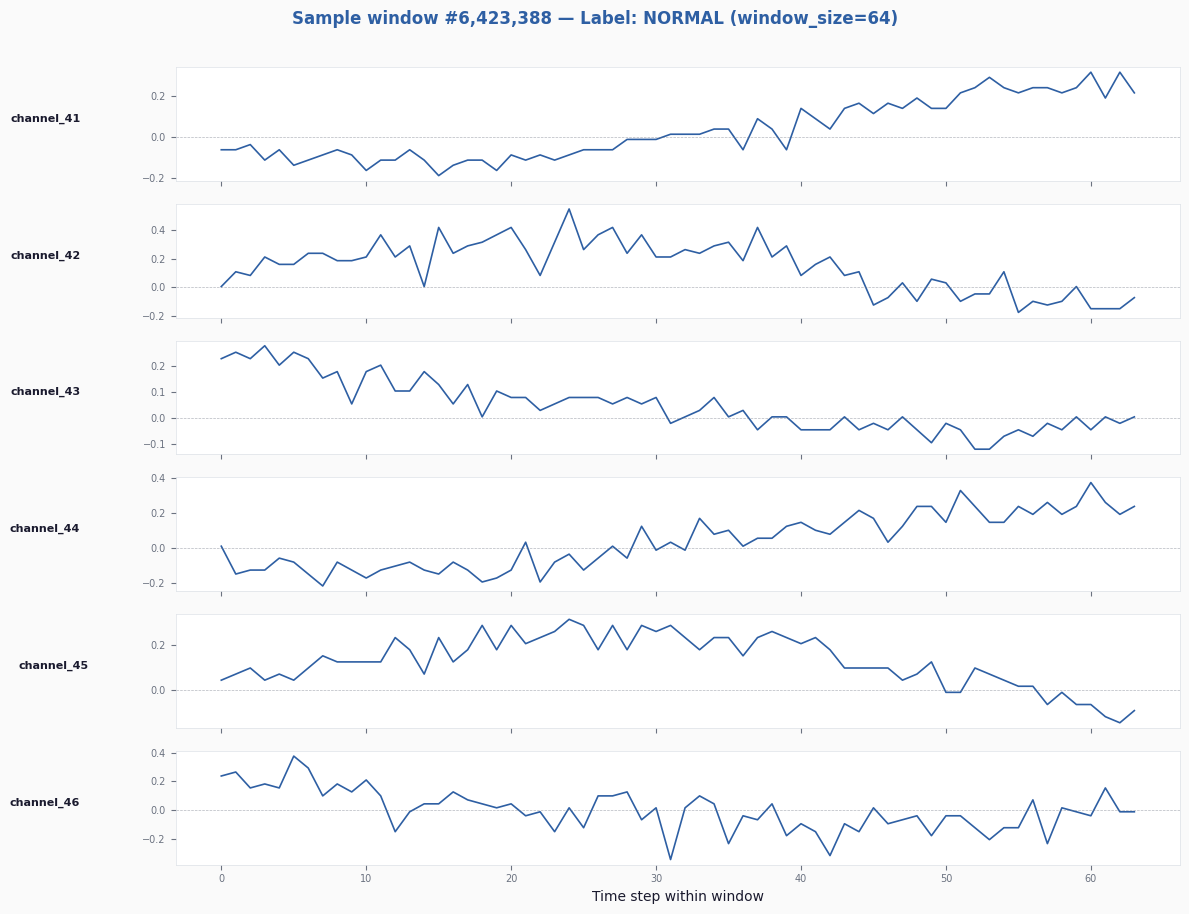

In [11]:
# Plotting the sample window

fig, axes = plt.subplots(6, 1, figsize=(12, 9), sharex=True, facecolor=BG)
fig.patch.set_facecolor(BG)

color = ANOMALY_C if label else NORMAL_C
title_label = "ANOMALY" if label else "NORMAL"

for i, col in enumerate(starter_cols):
    ax = axes[i]
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color("#DDE1E7")
        spine.set_linewidth(0.5)

    ax.plot(sample[:, i], color=color, lw=1.2)
    ax.axhline(0, color=TEXT_GRAY, lw=0.5, ls="--", alpha=0.5)
    ax.set_ylabel(col, fontsize=8, fontweight="bold",
                  color=TEXT_DARK, rotation=0, labelpad=70)
    ax.tick_params(labelsize=7, colors=TEXT_GRAY)

axes[-1].set_xlabel("Time step within window", fontsize=10, color=TEXT_DARK)

plt.suptitle(f"Sample window #{idx:,} — Label: {title_label} "
             f"(window_size={WINDOW_SIZE})",
             fontsize=12, fontweight="bold", color=color, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_window.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Save Processed Arrays

In [12]:
np.save(DATA_PROC / "X_train_starter.npy", X_train)
np.save(DATA_PROC / "y_train_starter.npy", y_train)
np.save(DATA_PROC / "X_test_starter.npy",  X_test)

print("Saved :")
for fname in ["X_train_starter.npy", "y_train_starter.npy", "X_test_starter.npy"]:
    path = DATA_PROC / fname
    size = path.stat().st_size / 1e6
    print(f"  {path}  ({size:.1f} MB)")

Saved :
  ../data/processed/X_train_starter.npy  (22622.6 MB)
  ../data/processed/y_train_starter.npy  (14.7 MB)
  ../data/processed/X_test_starter.npy  (800.6 MB)


In [13]:
config = {
    "starter_channels" : starter_cols,
    "window_size"      : WINDOW_SIZE,
    "stride"           : STRIDE,
    "label_strategy"   : "any - window=1 if at least one point is anomalous",
    "scaler"           : "StandardScaler fitted on train only",
    "scaler_path"      : str(scaler_path),
    "shapes": {
        "X_train" : list(X_train.shape),
        "y_train" : list(y_train.shape),
        "X_test"  : list(X_test.shape),
    },
    "window_label_stats": {
        "n_total"      : int(n_win_total),
        "n_normal"     : int(n_win_normal),
        "n_anomaly"    : int(n_win_anomaly),
        "anomaly_ratio": float(win_ratio),
        "pos_weight"   : float(pos_weight),
    }
}

config_path = RESULTS_DIR / "preprocessing_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Config saved to {config_path}")

Config saved to ../results/metrics/preprocessing_config.json
